# Bibliotecas

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import mu_0

# Leitura de Dados

In [8]:
df = pd.read_csv(r"G:\Meu Drive\01 - Faculdade\TCC\python\Curva_B_H_Sem_Perdas.txt", sep=' ') # Leitura do Arquivo
df.columns = ["H", "B"] # Renomear as Colunas
display(df)

,H,B
0,0.000,0.0
1,663.146,1.0
2,1067.500,1.1
3,1705.230,1.2
4,2463.110,1.3
5,3841.670,1.4
6,5425.740,1.5
7,7957.750,1.6
8,12298.300,1.7
9,20462.800,1.8


# Cálculo de μr 

### $\mu_r = \frac{dB}{dH} \cdot \frac{1}{\mu_o}$

In [10]:
dBdH = np.gradient(df["B"], df["H"])
mir = dBdH * 1 / mu_0
mir = np.insert(mir, 0, 0)
mir = mir[:-1]
mir

array([0.00000000e+00, 1.19999927e+03, 5.76798715e+02, 1.68856325e+02,
       1.15742783e+02, 8.82297680e+01, 5.42403218e+01, 4.29980296e+01,
       2.66040478e+01, 1.53530120e+01, 8.53502173e+00, 5.63186984e+00,
       2.31673340e+00, 1.36729631e+00, 1.01728273e+00, 1.00084953e+00])

# Gráficos

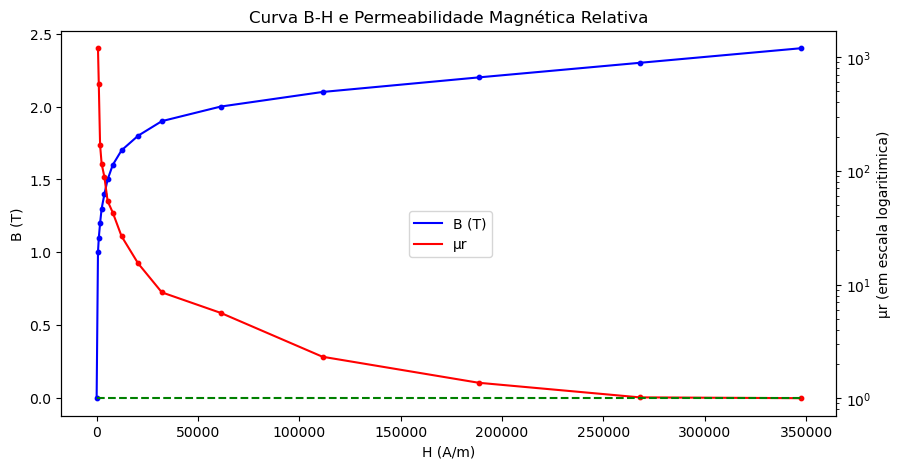

In [15]:
# Criar figura
fig, ax1 = plt.subplots(figsize=(10, 5))

# Eixo 1 (esquerda) → B
ax1.scatter(df["H"], df["B"], c='blue', s=10)
ax1.plot(df["H"], df["B"], c='blue', label='B (T)')
ax1.set_xlabel("H (A/m)")
ax1.set_ylabel("B (T)")

# Eixo 2 (direita) → μr
ax2 = ax1.twinx()
ax2.scatter(df["H"][1:], mir[1:], c='red', s=10)
ax2.plot(df["H"][1:], mir[1:], c='red', label='μr')
ax2.plot([0, max(df["H"].tolist())], [1, 1], c='green', linestyle='--')
ax2.set_yscale('log')
ax2.set_ylabel("μr (em escala logaritimica)")

fig.legend(loc=10)
plt.title('Curva B-H e Permeabilidade Magnética Relativa')
plt.savefig(r"G:\Meu Drive\01 - Faculdade\TCC\python\Curva_B_H_Sem_Perdas.png", dpi=300, bbox_inches="tight")
plt.show()

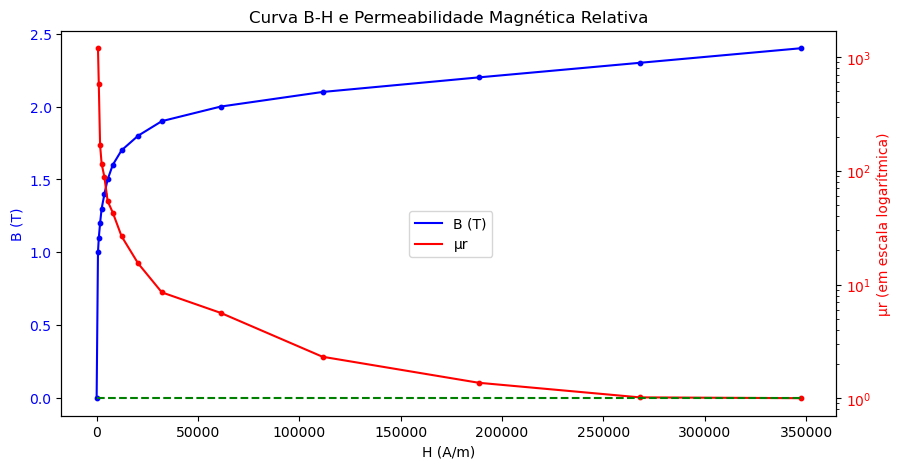

In [16]:
# Criar figura
fig, ax1 = plt.subplots(figsize=(10, 5))

# Eixo 1 (esquerda) → B
ax1.scatter(df["H"], df["B"], c='blue', s=10)
ax1.plot(df["H"], df["B"], c='blue', label='B (T)')
ax1.set_xlabel("H (A/m)")
ax1.set_ylabel("B (T)", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Eixo 2 (direita) → μr
ax2 = ax1.twinx()
ax2.scatter(df["H"][1:], mir[1:], c='red', s=10)
ax2.plot(df["H"][1:], mir[1:], c='red', label='μr')
ax2.plot([0, max(df["H"].tolist())], [1, 1], c='green', linestyle='--')
ax2.set_yscale('log')
ax2.set_ylabel("μr (em escala logarítmica)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

fig.legend(loc=10)
plt.title('Curva B-H e Permeabilidade Magnética Relativa')
plt.savefig(r"G:\Meu Drive\01 - Faculdade\TCC\python\Curva_B_H_Sem_Perdas_.png", dpi=300, bbox_inches="tight")
plt.show()

# Tabela

In [17]:
df['μr'] = mir
display(df)
df.to_excel(r"G:\Meu Drive\01 - Faculdade\TCC\python\Curva_B_H_Sem_Perdas.xlsx", index=False)

,H,B,μr
0,0.000,0.0,0.000000
1,663.146,1.0,1199.999269
2,1067.500,1.1,576.798715
3,1705.230,1.2,168.856325
4,2463.110,1.3,115.742783
5,3841.670,1.4,88.229768
6,5425.740,1.5,54.240322
7,7957.750,1.6,42.998030
8,12298.300,1.7,26.604048
9,20462.800,1.8,15.353012
